In [97]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [98]:
df = pd.DataFrame()

In [99]:
df['x1'] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['x2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df['label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

In [100]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

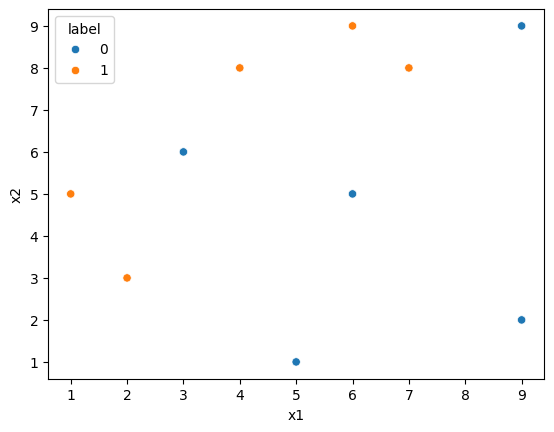

In [101]:
import seaborn as sns
sns.scatterplot(x = df['x1'], y=df['x2'], hue = df['label'])

In [102]:
df['weights'] = 1/df.shape[0]

In [103]:
df

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [104]:
from sklearn.tree import DecisionTreeClassifier

In [105]:
dt1 = DecisionTreeClassifier(max_depth=1)# max_depth =1 as decision stump is of single node only

In [106]:
x = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [107]:
dt1.fit(x, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

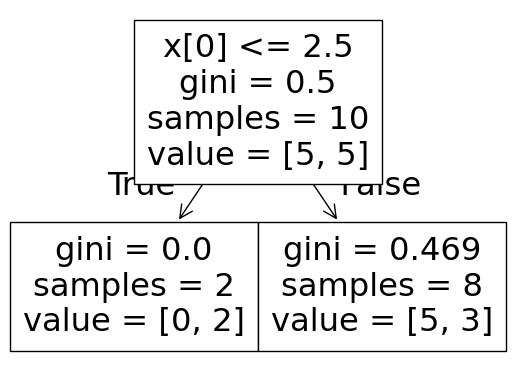

In [108]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

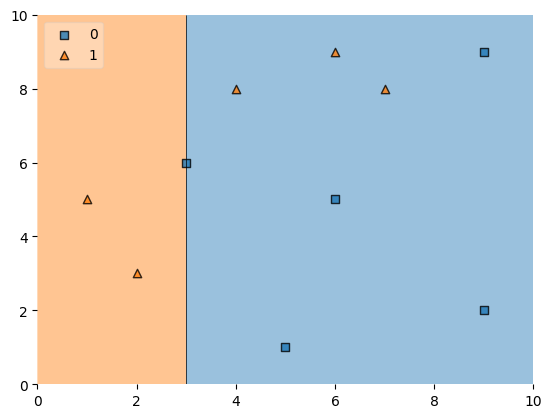

In [109]:
plot_decision_regions(x, y, clf=dt1, legend=2)

In [110]:
df['y_pred'] = dt1.predict(x)

In [111]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [112]:
def calculate_model_weight(error):#this is to calculate alpha
  return 0.5*np.log((1-error)/(error + 0.0000001))

In [113]:
error_wt = 0.0
for _, row in df.iterrows():
    if row['label'] != row['y_pred']:
        error_wt += row['weights']

print(error_wt)

0.30000000000000004


In [114]:
# Step 3 = calculate model wt
alpha1 = calculate_model_weight(error_wt)
alpha1

np.float64(0.4236487635269628)

In [115]:
#Step 4 =  update wts
def update_row_wts(row, alpha=alpha1):
  if(row['label'] == row['y_pred']):
     return row['weights'] * np.exp(-alpha1)
  else:
    return row['weights'] * np.exp(alpha1)

In [116]:
df['updated_wts'] = df.apply(update_row_wts, axis=1)

In [117]:
df

,x1,x2,label,weights,y_pred,updated_wts
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,0,0.065465
3,4,8,1,0.1,0,0.152752
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,0,0.152752
6,6,5,0,0.1,0,0.065465
7,7,8,1,0.1,0,0.152752
8,9,9,0,0.1,0,0.065465
9,9,2,0,0.1,0,0.065465


In [118]:
df['normalized_wts'] = df['updated_wts']/df['updated_wts'].sum()

In [119]:
df

,x1,x2,label,weights,y_pred,updated_wts,normalized_wts
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,0,0.065465,0.071429
3,4,8,1,0.1,0,0.152752,0.166667
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,0,0.152752,0.166667
6,6,5,0,0.1,0,0.065465,0.071429
7,7,8,1,0.1,0,0.152752,0.166667
8,9,9,0,0.1,0,0.065465,0.071429
9,9,2,0,0.1,0,0.065465,0.071429


In [120]:
df['normalized_wts'].sum()

np.float64(0.9999999999999998)

In [121]:
df['cumsum_upper'] = np.cumsum(df['normalized_wts'])

In [122]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_wts']

In [123]:
df[['x1', 'x2', 'label', 'weights', 'y_pred', 'updated_wts', 'cumsum_lower', 'cumsum_upper']]

,x1,x2,label,weights,y_pred,updated_wts,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065465,0.000000,0.071429
1,2,3,1,0.1,1,0.065465,0.071429,0.142857
2,3,6,0,0.1,0,0.065465,0.142857,0.214286
3,4,8,1,0.1,0,0.152752,0.214286,0.380952
4,5,1,0,0.1,0,0.065465,0.380952,0.452381
5,6,9,1,0.1,0,0.152752,0.452381,0.619048
6,6,5,0,0.1,0,0.065465,0.619048,0.690476
7,7,8,1,0.1,0,0.152752,0.690476,0.857143
8,9,9,0,0.1,0,0.065465,0.857143,0.928571
9,9,2,0,0.1,0,0.065465,0.928571,1.000000


In [124]:
def create_new_dataset(df):
  indices = []
  for i in range(df.shape[0]):
    a = np.random.rand()
    for index,row in df.iterrows():
      if(a > row['cumsum_lower'] and a < row['cumsum_upper']):
        indices.append(index)
  return indices

In [125]:
index_values = create_new_dataset(df)

In [126]:
index_values

[8, 1, 3, 5, 6, 8, 0, 3, 5, 9]

In [127]:
#Now first stage is complete and now going to second stage
second_df = df.iloc[index_values, [0, 1, 2, 3]]

In [128]:
second_df

,x1,x2,label,weights
8,9,9,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1
0,1,5,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
9,9,2,0,0.1


In [129]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [130]:
x = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [131]:
dt2.fit(x, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 7.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

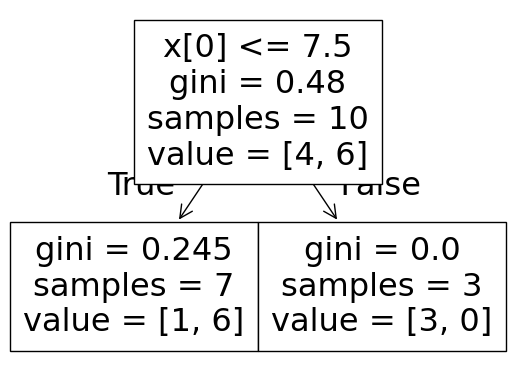

In [132]:
from sklearn.tree import plot_tree
plot_tree(dt2)

<Axes: >

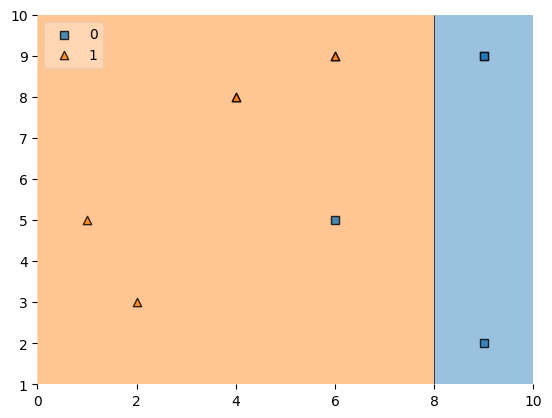

In [133]:
plot_decision_regions(x, y, clf=dt2, legend=2)

In [134]:
second_df['y_pred'] = dt2.predict(x)

In [135]:
error_wt = 0.0
for _, row in second_df.iterrows():
    if row['label'] != row['y_pred']:
        error_wt += row['weights']

print(error_wt)

0.1


In [136]:
# Step 3 = calculate model wt
alpha2 = calculate_model_weight(error_wt)
alpha2

np.float64(1.0986117886683595)

In [137]:
#Step 4 =  update wts
def update_row_wts(row, alpha=alpha2):
  if(row['label'] == row['y_pred']):
     return row['weights'] * np.exp(-alpha2)
  else:
    return row['weights'] * np.exp(alpha2)

In [138]:
second_df['updated_wts'] = second_df.apply(update_row_wts, axis=1)

In [139]:
second_df

,x1,x2,label,weights,y_pred,updated_wts
8,9,9,0,0.1,0,0.033333
1,2,3,1,0.1,1,0.033333
3,4,8,1,0.1,1,0.033333
5,6,9,1,0.1,1,0.033333
6,6,5,0,0.1,1,0.300000
8,9,9,0,0.1,0,0.033333
0,1,5,1,0.1,1,0.033333
3,4,8,1,0.1,1,0.033333
5,6,9,1,0.1,1,0.033333
9,9,2,0,0.1,0,0.033333


In [140]:
second_df['updated_wts'].sum()

np.float64(0.600000000000075)

In [141]:
second_df['normalized_wts'] = second_df['updated_wts']/second_df['updated_wts'].sum()

In [142]:
second_df

,x1,x2,label,weights,y_pred,updated_wts,normalized_wts
8,9,9,0,0.1,0,0.033333,0.055556
1,2,3,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
5,6,9,1,0.1,1,0.033333,0.055556
6,6,5,0,0.1,1,0.300000,0.500000
8,9,9,0,0.1,0,0.033333,0.055556
0,1,5,1,0.1,1,0.033333,0.055556
3,4,8,1,0.1,1,0.033333,0.055556
5,6,9,1,0.1,1,0.033333,0.055556
9,9,2,0,0.1,0,0.033333,0.055556


In [143]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_wts'])

In [144]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_wts']

In [145]:
second_df[['x1', 'x2', 'label', 'weights', 'y_pred', 'updated_wts', 'cumsum_lower', 'cumsum_upper']]

,x1,x2,label,weights,y_pred,updated_wts,cumsum_lower,cumsum_upper
8,9,9,0,0.1,0,0.033333,0.000000,0.055556
1,2,3,1,0.1,1,0.033333,0.055556,0.111111
3,4,8,1,0.1,1,0.033333,0.111111,0.166667
5,6,9,1,0.1,1,0.033333,0.166667,0.222222
6,6,5,0,0.1,1,0.300000,0.222222,0.722222
8,9,9,0,0.1,0,0.033333,0.722222,0.777778
0,1,5,1,0.1,1,0.033333,0.777778,0.833333
3,4,8,1,0.1,1,0.033333,0.833333,0.888889
5,6,9,1,0.1,1,0.033333,0.888889,0.944444
9,9,2,0,0.1,0,0.033333,0.944444,1.000000


In [146]:
def create_new_dataset(second_df):
  indices = []
  for i in range(second_df.shape[0]):
    a = np.random.rand()
    for index,row in second_df.iterrows():
      if(a > row['cumsum_lower'] and a < row['cumsum_upper']):
        indices.append(index)
  return indices

In [147]:
index_values = create_new_dataset(second_df)

In [148]:
index_values

[6, 5, 6, 6, 8, 6, 6, 6, 6, 8]

In [149]:
third_df = second_df.iloc[index_values, [0, 1, 2, 3]]

In [150]:
third_df

,x1,x2,label,weights
0,1,5,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1
0,1,5,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
0,1,5,1,0.1
0,1,5,1,0.1
0,1,5,1,0.1
5,6,9,1,0.1


In [151]:
dt3 = DecisionTreeClassifier(max_depth=1)

In [152]:
x = third_df.iloc[:, 0:2].values
y = third_df.iloc[:, 2].values
dt3.fit(x, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 7.5\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.625, 0.5, '  False')]

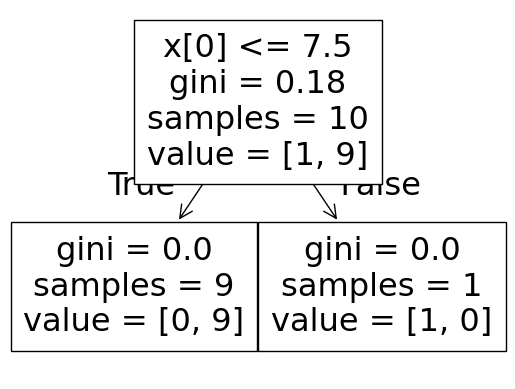

In [153]:
from sklearn.tree import plot_tree
plot_tree(dt3)

<Axes: >

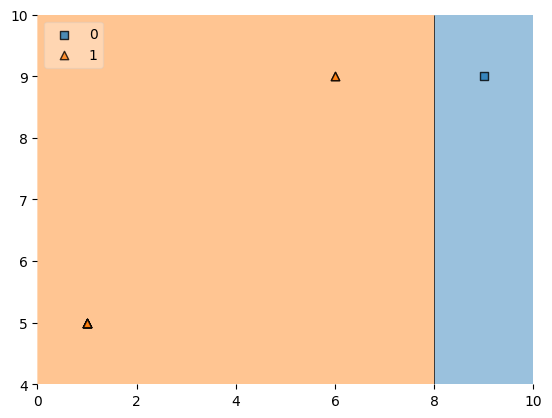

In [154]:
plot_decision_regions(x, y, clf=dt3, legend=2)

In [155]:
third_df['y_pred'] = dt3.predict(x)

In [156]:
third_df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
8,9,9,0,0.1,0
0,1,5,1,0.1,1
0,1,5,1,0.1,1
5,6,9,1,0.1,1
0,1,5,1,0.1,1
0,1,5,1,0.1,1
0,1,5,1,0.1,1
0,1,5,1,0.1,1
5,6,9,1,0.1,1


In [157]:
alpha3 = calculate_model_weight(0.1)
alpha3

np.float64(1.0986117886683595)

In [158]:
print(alpha1, alpha2, alpha3)

0.4236487635269628 1.0986117886683595 1.0986117886683595


Prediction

In [160]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [161]:
dt2.predict(query)

array([1])

In [162]:
dt3.predict(query)

array([1])

In [163]:
A = alpha1*1 + alpha2*1 + alpha3*1
A

np.float64(2.6208723408636816)

In [164]:
np.sign(A)

np.float64(1.0)

In [165]:
query = np.array([6,5]).reshape(1,2)
dt1.predict(query)

array([0])

In [168]:
dt2.predict(query)

array([1])

In [169]:
dt3.predict(query)

array([1])

In [170]:
A = alpha1*(-1) + alpha2*(1) + alpha3*(1)#in boosting case 0 is taken as -1, (0 from array([0]))
A

np.float64(-1.7735748138097562)

In [171]:
np.sign(A)

np.float64(-1.0)